In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
from sklearn.ensemble import IsolationForest
from sqlalchemy import create_engine
from urllib.parse import quote_plus 

%matplotlib inline

In [2]:
DB_USER = "myvolt_admin" 
DB_PASS = "M%R^N!J%IDKS$8@zya4v"
DB_HOST = "myvolt-db.postgres.database.azure.com"
DB_PORT = "5432"
DB_NAME = "postgres" 

DB_PASS_ENCODED = quote_plus(DB_PASS)

try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
    engine = create_engine(connection_string)
    with engine.connect() as conn:
        print("¡Conexión a Azure PostgreSQL exitosa!")
except Exception as e:
    print(f"Error al conectar a Azure: {e}")

¡Conexión a Azure PostgreSQL exitosa!


In [14]:
query = """
SELECT time, power_w
FROM consumption_data
WHERE id_device = (
    SELECT id_device 
    FROM devices 
    WHERE mac_address = 'B0:A7:32:34:54:9C'
)
ORDER BY time DESC
LIMIT 2500; 
"""

df = pd.read_sql_query(query, con=engine)
print(f"Se cargaron {len(df)} registros (los más recientes) desde la base de datos.")
df.head()

Se cargaron 2500 registros (los más recientes) desde la base de datos.


,time,power_w
0,2025-11-07 04:57:50.715450+00:00,3.74
1,2025-11-07 04:57:50.514445+00:00,5.84
2,2025-11-07 04:57:50.315696+00:00,2.37
3,2025-11-07 04:57:50.115372+00:00,1.66
4,2025-11-07 04:57:49.914240+00:00,1.67


In [15]:
datos_para_modelo = df[['power_w']]
datos_para_modelo.head()

,power_w
0,3.74
1,5.84
2,2.37
3,1.66
4,1.67


In [16]:
modelo_if = IsolationForest(contamination=0.1, random_state=42)
modelo_if.fit(datos_para_modelo)
print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


In [17]:
predicciones = modelo_if.predict(datos_para_modelo)
df['anomalia_predicha'] = predicciones
anomalias = df[df['anomalia_predicha'] == -1]
print(f"El modelo detectó {len(anomalias)} anomalías de un total de {len(df)} registros.")
print("\nEjemplos de potencias anómalas (W) encontradas:")
print(anomalias['power_w'].value_counts().head())

El modelo detectó 250 anomalías de un total de 2500 registros.

Ejemplos de potencias anómalas (W) encontradas:
power_w
133.00    2
58.38     2
123.95    2
143.05    2
133.47    2
Name: count, dtype: int64


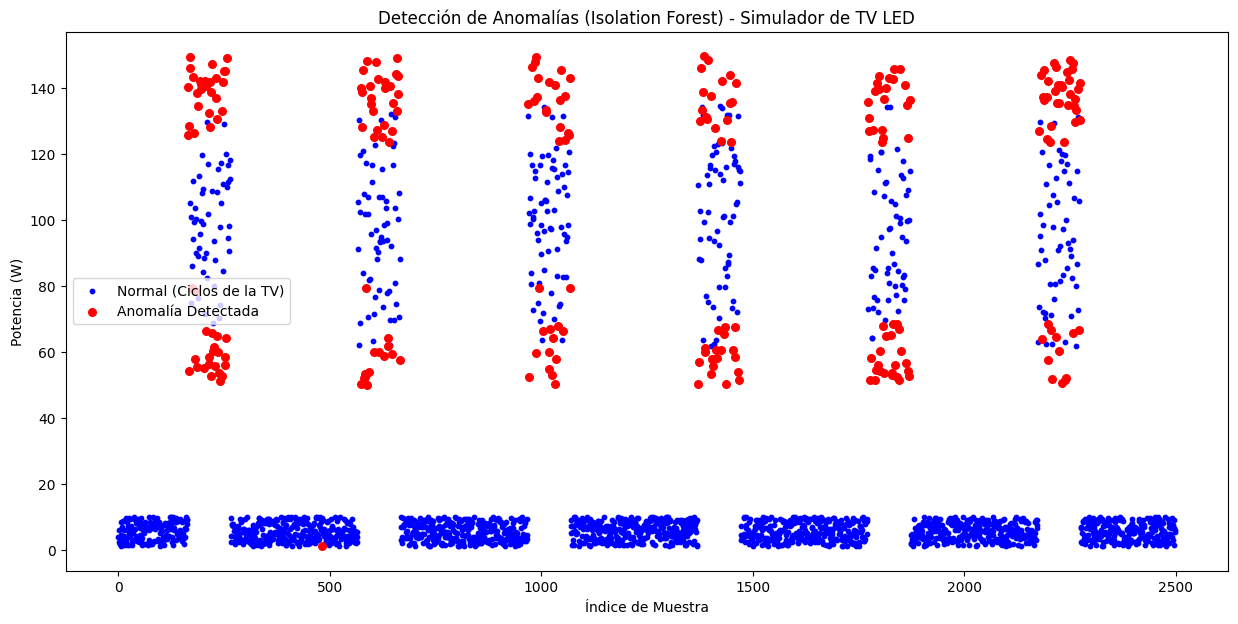

In [ ]:
df_normal = df[df['anomalia_predicha'] == 1]
df_anomalo = df[df['anomalia_predicha'] == -1]

plt.figure(figsize=(15, 7))

# Pintamos los puntos normales en azul
# AHORA DEBERÍAS VER DOS LÍNEAS: una entre 1-10W y otra entre 50-150W
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal (Ciclos de la TV)', s=10)

# Pintamos las anomalías en rojo
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía Detectada', s=30)

plt.title('Detección de Anomalías (Isolation Forest) - Simulador de TV LED')

plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [20]:
ruta_modelo = '../models/models_v1/tv_led_model_v1.pkl' 

joblib.dump(modelo_if, ruta_modelo)

print(f"¡Modelo de la TV LED guardado exitosamente en {ruta_modelo}!")

¡Modelo de la TV LED guardado exitosamente en ../models/models_v1/tv_led_model_v1.pkl!
